In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

In [2]:
df = pd.read_csv('bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [3]:
X = df.drop('pIC50', axis=1)
Y = df.pIC50

In [4]:
# Examine X dimension
X.shape

(586, 881)

In [5]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))    
X = selection.fit_transform(X)
X.shape

(586, 153)

In [6]:
# Perform data splitting using 80/20 ratio
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [17]:
# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None)
train,test  = clf.fit(X_train, X_test, Y_train, Y_test)

In [18]:
# Performance table of the training set (80% subset)
train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
Lars,1.381615e+55,-4.251124e+54,3.491920e+27,0.055922
KernelRidge,4.833687e+01,-1.356519e+01,6.463542e+00,0.028331
GaussianProcessRegressor,2.325893e+01,-5.848903e+00,4.432237e+00,0.074774
RANSACRegressor,5.369856e+00,-3.445711e-01,1.963832e+00,1.372090
QuantileRegressor,4.660088e+00,-1.261809e-01,1.797283e+00,2.390486
DummyRegressor,4.267431e+00,-5.363488e-03,1.698142e+00,0.011737
Lasso,4.064791e+00,5.698732e-02,1.644641e+00,0.016217
LassoLars,4.064791e+00,5.698732e-02,1.644641e+00,0.065150
ElasticNet,3.304237e+00,2.910040e-01,1.426049e+00,0.016487


In [21]:
# Performance table of the test set (20% subset)
test

""


[(0.0, 1.0)]

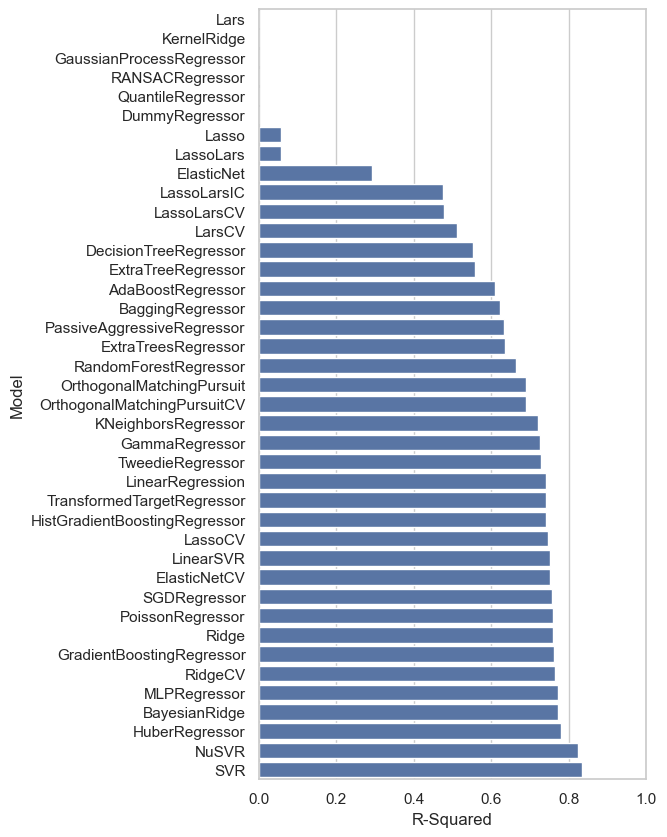

In [24]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=train.index, x="R-Squared", data=train)
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

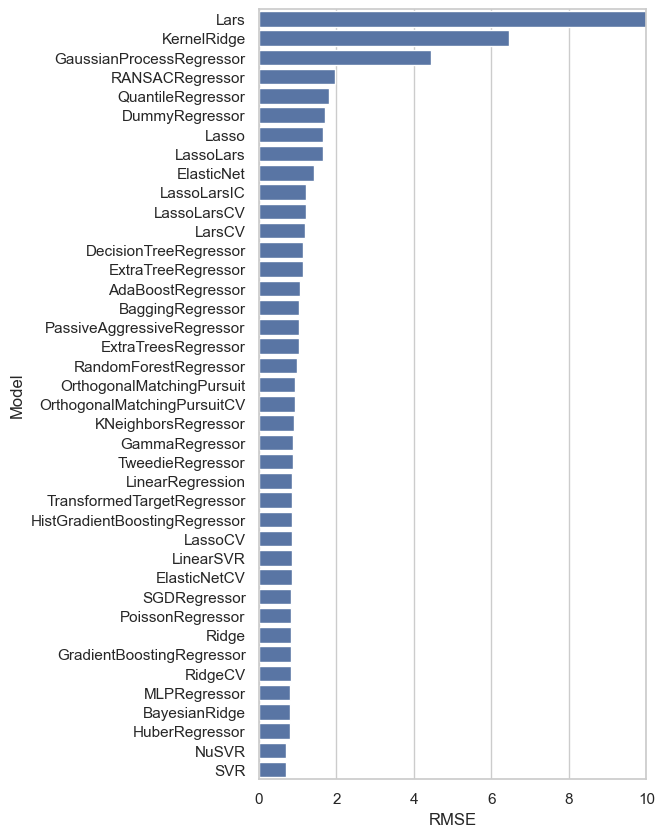

In [25]:
# Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=train.index, x="RMSE", data=train)
ax.set(xlim=(0, 10))

[(0.0, 10.0)]

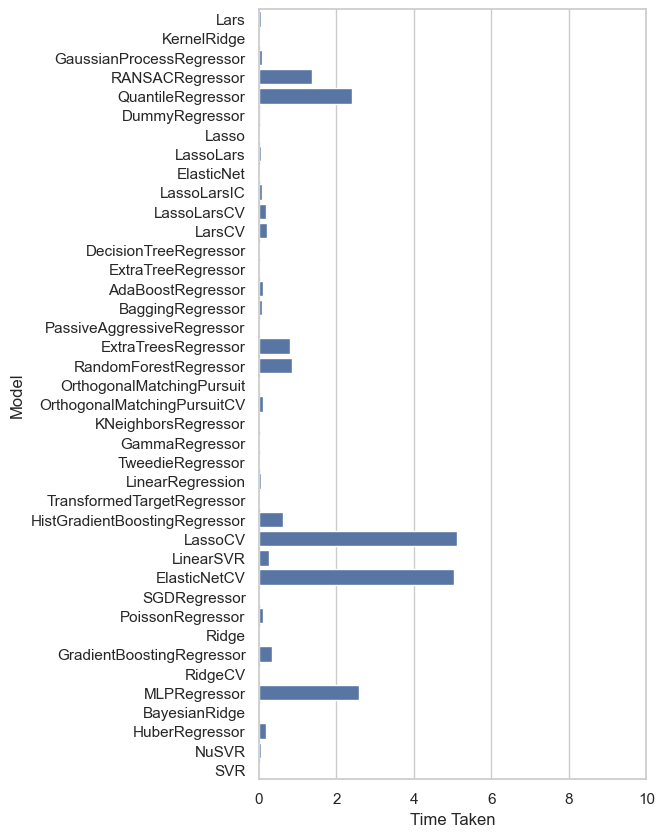

In [26]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=train.index, x="Time Taken", data=train)
ax.set(xlim=(0, 10))